# GeoLife EDA — Báo cáo CP1

**Mục tiêu:** tái lập toàn bộ EDA quan trọng phục vụ Checkpoint 1: làm sạch GPS, chuẩn bị stay-point detection, và đưa ra các quyết định preprocessing có evidence.

> **Quan trọng về label interval:** phiên bản notebook này dùng quy ước chuẩn **half-open `[start, end)`**. Hai interval khác mode chỉ chạm nhau tại endpoint **không** được coi là overlap thật. Đây là correction sau independent audit.

### Scope

EDA này tập trung vào:

1. quy mô và imbalance của dataset;
2. chất lượng timestamp / coordinate;
3. duplicate timestamps và độ chính xác thời gian;
4. same-second spatial spread;
5. exact duplicate trajectories và leakage;
6. same-second consolidation;
7. segment speed + temporal gap;
8. transportation labels và speed plausibility;
9. proposal cho cleaning contract trước khi implement stay-point.

**Không** dùng transportation labels làm Home/Office ground truth.

## Cách chạy

Notebook được thiết kế để chạy trên Modal volume hiện tại (`/mnt/geolife-data`) nhưng vẫn hỗ trợ `GEOLIFE_DATA_ROOT` nếu chạy nơi khác.

Các full scan đắt tiền được cache bằng `pickle` trong `/mnt/geolife-data/eda_cache`. Vì vậy:

- lần đầu có thể mất thời gian;
- các lần `Run All` sau sẽ load cache;
- không cần `pyarrow`;
- không commit raw GPS, cache, hoặc user-level derived artifacts lên Git.

Nếu repo local chưa có, notebook sẽ clone `main` của `tanh1c/geolife` để dùng `notebooks/eda_core.py`.

In [1]:
from pathlib import Path
from time import perf_counter
from collections import defaultdict, Counter
from IPython.display import display, Markdown
import hashlib
import inspect
import os
import subprocess
import sys
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

VOLUME_ROOT = Path(os.environ.get("GEOLIFE_VOLUME_ROOT", "/mnt/geolife-data"))
CACHE_DIR = VOLUME_ROOT / "eda_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

FORCE_REBUILD_RAW_SUMMARY = False
FORCE_REBUILD_SAME_SECOND = False
FORCE_REBUILD_HASHES = False
FORCE_REBUILD_CONSOLIDATED = False
FORCE_REBUILD_LABEL_V3 = False

print("VOLUME_ROOT:", VOLUME_ROOT)
print("CACHE_DIR:", CACHE_DIR)

VOLUME_ROOT: /mnt/geolife-data
CACHE_DIR: /mnt/geolife-data/eda_cache


## 0. Resolve dataset + import EDA helpers

Nguồn dữ liệu là Microsoft GeoLife Trajectories v1.3. `Data/` phải chứa 182 user folders (`000`...).

Notebook ưu tiên đường dẫn trong biến môi trường. Nếu chưa set, nó tìm thư mục `Data` đã extract; nếu chỉ còn ZIP thì extract một lần vào volume.

In [2]:
def count_user_dirs(path: Path) -> int:
    if not path.exists() or not path.is_dir():
        return 0
    return sum(1 for p in path.iterdir() if p.is_dir() and p.name.isdigit())

env_root = os.environ.get("GEOLIFE_DATA_ROOT")

if env_root:
    DATA_ROOT = Path(env_root)
else:
    candidates = [
        p for p in VOLUME_ROOT.rglob("Data")
        if p.is_dir() and count_user_dirs(p) == 182
    ]

    if not candidates:
        zip_files = sorted(VOLUME_ROOT.glob("*.zip"))
        if not zip_files:
            raise FileNotFoundError(
                "Không tìm thấy GeoLife Data folder hoặc ZIP. "
                "Set GEOLIFE_DATA_ROOT hoặc mount dataset vào /mnt/geolife-data."
            )

        extract_root = VOLUME_ROOT / "extracted"
        extract_root.mkdir(parents=True, exist_ok=True)

        print("Extracting:", zip_files[0])
        with zipfile.ZipFile(zip_files[0]) as zf:
            zf.extractall(extract_root)

        candidates = [
            p for p in extract_root.rglob("Data")
            if p.is_dir() and count_user_dirs(p) == 182
        ]

    if not candidates:
        raise RuntimeError("Extract xong nhưng không tìm được Data/ có 182 user folders.")

    DATA_ROOT = candidates[0]

print("DATA_ROOT:", DATA_ROOT)
print("User dirs:", count_user_dirs(DATA_ROOT))
assert count_user_dirs(DATA_ROOT) == 182

DATA_ROOT: /mnt/geolife-data/extracted/Geolife Trajectories 1.3/Data
User dirs: 182


In [3]:
REPO_DIR = Path(os.environ.get("GEOLIFE_REPO_DIR", "/tmp/geolife"))
REPO_URL = "https://github.com/tanh1c/geolife.git"

def ensure_repo():
    # Nếu đang chạy từ repo local thì dùng luôn.
    cwd = Path.cwd()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "notebooks" / "eda_core.py").exists():
            return candidate

    if (REPO_DIR / ".git").exists():
        subprocess.run(
            ["git", "-C", str(REPO_DIR), "fetch", "origin", "main"],
            check=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
        )
        subprocess.run(
            ["git", "-C", str(REPO_DIR), "checkout", "main"],
            check=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
        )
        subprocess.run(
            ["git", "-C", str(REPO_DIR), "reset", "--hard", "origin/main"],
            check=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
        )
    else:
        subprocess.run(
            ["git", "clone", "--depth", "1", "--branch", "main", REPO_URL, str(REPO_DIR)],
            check=True,
        )
    return REPO_DIR

repo_root = ensure_repo()
sys.path.insert(0, str(repo_root))

from notebooks.eda_core import (
    inventory_dataset,
    read_plt,
    summarize_trajectory,
    read_labels,
    haversine_vectorized,
)

print("Repo root:", repo_root)
print("EDA helper:", inspect.getsourcefile(read_plt))

Cloning into '/tmp/geolife'...


Repo root: /tmp/geolife
EDA helper: /tmp/geolife/notebooks/eda_core.py


# 1. Dataset inventory và user imbalance

### Câu hỏi

- Release thật có bao nhiêu users / trajectories / points?
- Bao nhiêu user có `labels.txt`?
- Lịch sử có cân bằng giữa users không?

### Tại sao quan trọng?

Home/Office inference cần **repeated behavior theo user**. Nếu một số user có hàng nghìn trajectories còn nhiều user chỉ có vài trajectories, metric global có thể bị heavy users chi phối.

In [4]:
inventory, all_files = inventory_dataset(DATA_ROOT)

print("Users:", len(inventory))
print("Trajectory files:", int(inventory["trajectory_count"].sum()))
print("Users with labels:", int(inventory["has_labels"].sum()))

display(
    inventory["trajectory_count"].describe(
        percentiles=[.01, .05, .25, .5, .75, .9, .95, .99]
    )
)

ranked = inventory.sort_values("trajectory_count", ascending=False).reset_index(drop=True)
total_files = int(ranked["trajectory_count"].sum())

for n in [1, 5, 10, 20, 50]:
    share = ranked.head(n)["trajectory_count"].sum() / total_files
    print(f"Top {n:2d} users: {share:.2%} trajectories")

display(
    inventory.groupby("has_labels")["trajectory_count"]
    .agg(users="count", total_trajectories="sum", mean="mean", median="median", min="min", max="max")
)

Users: 182
Trajectory files: 18670
Users with labels: 69


count     182.000000
mean      102.582418
std       250.063575
min         1.000000
1%          1.000000
5%          2.000000
25%         8.000000
50%        27.500000
75%        89.750000
90%       214.700000
95%       394.800000
99%      1039.850000
max      2153.000000
Name: trajectory_count, dtype: float64

Top  1 users: 11.53% trajectories
Top  5 users: 34.54% trajectories
Top 10 users: 47.38% trajectories
Top 20 users: 63.29% trajectories
Top 50 users: 84.00% trajectories


,users,total_trajectories,mean,median,min,max
has_labels,,,,,,
False,113,7764,68.707965,23.0,1,757
True,69,10906,158.057971,34.0,2,2153


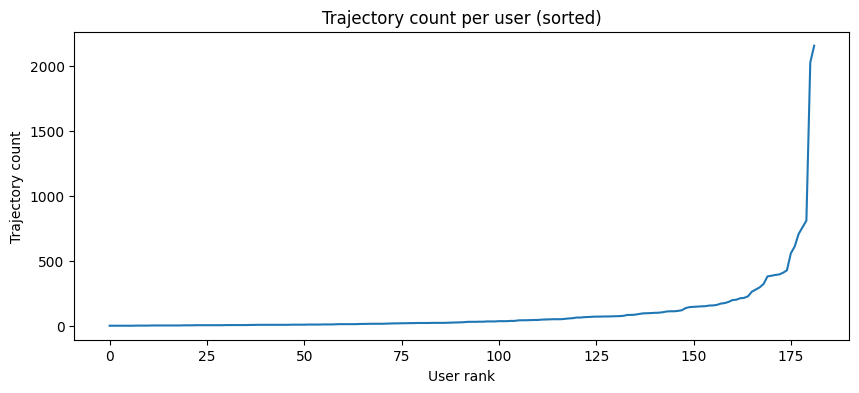

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
ranked["trajectory_count"].sort_values().reset_index(drop=True).plot(ax=ax)
ax.set(
    title="Trajectory count per user (sorted)",
    xlabel="User rank",
    ylabel="Trajectory count",
)
plt.show()

### Kết luận phần 1

Kết quả đã được audit độc lập từ ZIP gốc và khớp với EDA ban đầu:

- **182 users**
- **18,670 trajectory files**
- **69 user folders có labels**
- median **27.5 trajectories/user**
- max **2,153 trajectories/user**
- top 10 users đóng góp khoảng **47.4% trajectories**

**Quyết định:** Vì dữ liệu phân bổ lệch cực đoan (Top 10 users chiếm gần một nửa dữ liệu, và nhóm có nhãn có mật độ dữ liệu cao gấp nhiều lần nhóm không nhãn) 
- evaluation về sau bắt buộc phải có góc nhìn per-user / macro (tính toán metric cho từng user rồi lấy trung bình, hoặc chia tầng theo nhóm user), tuyệt đối không chỉ dựa vào point- hoặc trajectory-weighted global metric. Nếu dùng metric global thuần túy, kết quả đánh giá sẽ bị chi phối hoàn toàn bởi một vài "siêu user" ở phần đuôi, làm mất đi tính khách quan đối với phần lớn người dùng còn lại trong hệ thống.

# 2. Full raw scan: schema, timestamps, coordinates, sampling, speed

Ta reduce mỗi trajectory về một summary row thay vì concat ~25M GPS points vào một DataFrame lớn.

Đây là full scan đắt tiền, nhưng có cache + checkpoint.

In [6]:
def atomic_pickle_write(df: pd.DataFrame, path: Path) -> None:
    tmp = path.with_name(path.name + ".tmp")
    df.to_pickle(tmp)
    tmp.replace(path)

eda_core_path = Path(inspect.getsourcefile(read_plt))
eda_core_hash = hashlib.sha256(eda_core_path.read_bytes()).hexdigest()[:12]

TRAJ_CACHE = CACHE_DIR / f"trajectory_summary_raw_{eda_core_hash}.pkl"
TRAJ_PARTIAL = CACHE_DIR / f"trajectory_summary_raw_{eda_core_hash}.partial.pkl"

if TRAJ_CACHE.exists() and not FORCE_REBUILD_RAW_SUMMARY:
    start = perf_counter()
    print("Loading cached raw summary:", TRAJ_CACHE)
    traj = pd.read_pickle(TRAJ_CACHE)
    print(f"Loaded {len(traj):,} rows in {perf_counter() - start:.2f}s")
else:
    if FORCE_REBUILD_RAW_SUMMARY:
        TRAJ_PARTIAL.unlink(missing_ok=True)

    if TRAJ_PARTIAL.exists():
        partial = pd.read_pickle(TRAJ_PARTIAL)
        rows = partial.to_dict("records")
        done = set(zip(partial["user_id"], partial["trajectory_id"]))
        print(f"Resume: {len(done):,}/{len(all_files):,}")
    else:
        rows, done = [], set()

    start = perf_counter()
    newly_processed = 0

    for user_id, path in all_files:
        key = (user_id, path.stem)
        if key in done:
            continue

        rows.append(summarize_trajectory(user_id, path))
        done.add(key)
        newly_processed += 1

        if newly_processed % 1000 == 0:
            checkpoint = pd.DataFrame(rows)
            checkpoint["start_time"] = pd.to_datetime(checkpoint["start_time"], utc=True)
            checkpoint["end_time"] = pd.to_datetime(checkpoint["end_time"], utc=True)
            atomic_pickle_write(checkpoint, TRAJ_PARTIAL)

            elapsed = perf_counter() - start
            rate = newly_processed / elapsed
            remaining = len(all_files) - len(done)
            print(
                f"{len(done):,}/{len(all_files):,} | "
                f"{rate:.1f} files/s | ETA ~{remaining / rate / 60:.1f} min"
            )

    traj = pd.DataFrame(rows)
    traj["start_time"] = pd.to_datetime(traj["start_time"], utc=True)
    traj["end_time"] = pd.to_datetime(traj["end_time"], utc=True)
    atomic_pickle_write(traj, TRAJ_CACHE)
    TRAJ_PARTIAL.unlink(missing_ok=True)
    print("Saved:", TRAJ_CACHE)

Loading cached raw summary: /mnt/geolife-data/eda_cache/trajectory_summary_raw_35bad139f585.pkl
Loaded 18,670 rows in 0.03s


In [7]:
summary_cols = [
    "n_points",
    "duration_min",
    "distance_km",
    "median_sampling_s",
    "p95_sampling_s",
    "max_speed_kmh",
    "p99_speed_kmh",
    "missing_altitude_rate",
]

display(
    traj[summary_cols].describe(
        percentiles=[.01, .05, .25, .5, .75, .9, .95, .99]
    )
)

total_points = int(traj["n_points"].sum())
duplicate_rows = int(traj["duplicate_timestamp"].sum())
affected_duplicate_traj = int((traj["duplicate_timestamp"] > 0).sum())

print("Total GPS points:", f"{total_points:,}")
print("Null timestamps:", int(traj["null_timestamp"].sum()))
print("Non-monotonic trajectories:", int(traj["non_monotonic_timestamp"].sum()))
print("Duplicate timestamp rows:", f"{duplicate_rows:,}", f"({duplicate_rows / total_points:.2%})")
print("Trajectories affected by duplicate timestamps:", f"{affected_duplicate_traj:,}")
print("Invalid latitude:", int(traj["invalid_lat"].sum()))
print("Invalid longitude:", int(traj["invalid_lon"].sum()))

,n_points,duration_min,distance_km,median_sampling_s,p95_sampling_s,max_speed_kmh,p99_speed_kmh,missing_altitude_rate
count,18670.000000,18670.000000,18670.000000,18670.000000,18670.000000,1.867000e+04,1.867000e+04,18670.000000
mean,1332.457311,161.253701,69.237716,5.971505,34.483315,4.260625e+02,1.555529e+02,0.000589
std,2821.513811,259.992307,4047.146080,110.651879,475.933032,2.442290e+04,1.136271e+04,0.024267
min,3.000000,0.033333,0.000000,1.000000,1.000000,0.000000e+00,0.000000e+00,0.000000
1%,6.000000,0.500000,0.052293,1.000000,1.000000,9.021189e+00,8.415383e+00,0.000000
5%,28.000000,3.733333,0.478170,1.000000,2.000000,2.216049e+01,1.662164e+01,0.000000
25%,201.000000,16.833333,2.784437,2.000000,3.000000,6.213534e+01,3.955754e+01,0.000000
50%,506.000000,42.133333,10.081757,2.000000,5.000000,9.511112e+01,5.897086e+01,0.000000
75%,1367.000000,192.429167,22.450785,5.000000,6.000000,1.667196e+02,7.944489e+01,0.000000
90%,3323.100000,530.413333,51.656750,5.000000,25.665000,2.699859e+02,1.048419e+02,0.000000


Total GPS points: 24,876,978
Null timestamps: 0
Non-monotonic trajectories: 0
Duplicate timestamp rows: 698,900 (2.81%)
Trajectories affected by duplicate timestamps: 441
Invalid latitude: 1
Invalid longitude: 0


### Kết luận phần 2

Các số nền đã được independent audit và tái lập:

- **24,876,978 points**
- **698,900 duplicate-timestamp rows** (~2.81%), ảnh hưởng **441 trajectories** (chỉ 441 trajectories có ít nhất một timestamp xuất hiện nhiều hơn một lần), được tính cộng dồn từ các trajectory, duplicate được tính ở trong cùng 1 trajectory
- **0** null timestamps
- **0** trajectories đảo thứ tự timestamp
- **1** malformed latitude
- tồn tại các movement anomaly rất cực đoan, bao gồm pattern nhảy hàng trăm km chỉ trong khoảng một giây

Có hai bài học preprocessing khác nhau:

- Thứ nhất, same-second observations không thể được coi là các movement segment thông thường, vì Δt = 0 nên speed không xác định. Chúng cần được phân tích và xử lý riêng trước khi tính movement speed.
- Thứ hai, malformed coordinate và impossible movement là hai failure modes khác nhau:
- invalid coordinate → lỗi trực tiếp ở một observation
- impossible jump → lỗi được phát hiện từ quan hệ giữa hai observations theo không gian + thời gian

**Quyết định**: preprocessing sẽ được thiết kế theo nhiều stage thay vì dùng một rule chung kiểu speed > X => drop point:
- coordinate validation → same-second handling → temporal / movement diagnostics → stay-point detection

Không tự động xóa một point chỉ vì segment có speed lớn, vì speed bất thường chỉ cho biết segment không đáng tin, chưa cho biết endpoint nào là point sai.

# 3. Root-cause spot checks: invalid coordinate + extreme movement

Ta kiểm tra trực tiếp các trajectory bất thường nhất để tránh suy luận chỉ từ summary statistic.

## 1) Check valid coordinate
1. **Lọc file lỗi:** Tìm các file trajectory có điểm kinh/vĩ độ nằm ngoài phạm vi địa lý của Trái Đất (vĩ độ ngoài $[-90, 90]$ hoặc kinh độ ngoài $[-180, 180]$).
2. **Mở file kiểm tra:** Đọc trực tiếp vào file bị lỗi đó.
3. **Soi dòng bị hỏng:** In chính xác dòng bị sai tọa độ kèm theo **3 dòng liền trước và 3 dòng liền sau** để xem ngữ cảnh (ví dụ: phát hiện gõ nhầm số như `400` thay vì `40`).

In [8]:
file_map = {(user_id, path.stem): path for user_id, path in all_files}

bad_coord_traj = traj[
    (traj["invalid_lat"] > 0) | (traj["invalid_lon"] > 0)
]

display(
    bad_coord_traj[
        ["user_id", "trajectory_id", "invalid_lat", "invalid_lon", "distance_km", "max_speed_kmh"]
    ]
)

for _, row in bad_coord_traj.iterrows():
    path = file_map[(row["user_id"], row["trajectory_id"])]
    df_bad = read_plt(path)
    mask = (
        ~df_bad["latitude"].between(-90, 90)
        | ~df_bad["longitude"].between(-180, 180)
    )
    bad_indices = np.flatnonzero(mask.to_numpy())
    for idx in bad_indices:
        display(df_bad.iloc[max(0, idx-3): idx+4])

,user_id,trajectory_id,invalid_lat,invalid_lon,distance_km,max_speed_kmh
2923,020,20110911000506,1,0,138.430671,427.978731


,latitude,longitude,unused,altitude_ft,serial_date,date,time,timestamp
6772,40.165983,116.216165,0,0.0,40797.141563,2011-09-11,03:23:51,2011-09-11 03:23:51+00:00
6773,40.166213,116.215905,0,0.0,40797.141574,2011-09-11,03:23:52,2011-09-11 03:23:52+00:00
6774,40.166440,116.215650,0,0.0,40797.141586,2011-09-11,03:23:53,2011-09-11 03:23:53+00:00
6775,400.166667,116.215390,0,0.0,40797.141597,2011-09-11,03:23:54,2011-09-11 03:23:54+00:00
6776,40.166892,116.215135,0,0.0,40797.141609,2011-09-11,03:23:55,2011-09-11 03:23:55+00:00
6777,40.167117,116.214882,0,0.0,40797.141620,2011-09-11,03:23:56,2011-09-11 03:23:56+00:00
6778,40.167343,116.214630,0,0.0,40797.141632,2011-09-11,03:23:57,2011-09-11 03:23:57+00:00


Có 1 trajectory có lỗi tọa độ latitude > 90 độ là của user 020 ở dòng 6775 latitude = 400.166667

## 2) Check speed spikes/GPS drift
1. **Tính vận tốc tức thời giữa từng cặp điểm GPS liên tiếp** (dựa vào khoảng cách mét chia số giây chênh lệch).
2. **Lấy ra file có tốc độ cao nhất toàn bộ dataset** (file chứa điểm bất thường nhất).
3. **In ra 30 bước nhảy có vận tốc "điên rồ" nhất** để soi chính xác giây nào và điểm nào bị văng tọa độ / lỗi GPS (speed spikes).

In [9]:
def segment_diagnostics(df: pd.DataFrame) -> pd.DataFrame:
    x = df.sort_values("timestamp").copy()
    x["dt_s"] = x["timestamp"].diff().dt.total_seconds()
    x["prev_lat"] = x["latitude"].shift(1)
    x["prev_lon"] = x["longitude"].shift(1)
    x["distance_m"] = haversine_vectorized(
        x["prev_lat"], x["prev_lon"], x["latitude"], x["longitude"]
    )
    valid = x["dt_s"].gt(0) & x["distance_m"].notna()
    x["speed_kmh"] = np.nan
    x.loc[valid, "speed_kmh"] = x.loc[valid, "distance_m"] / x.loc[valid, "dt_s"] * 3.6
    return x

worst = traj.sort_values("max_speed_kmh", ascending=False).iloc[0]
worst_path = file_map[(worst["user_id"], worst["trajectory_id"])]
worst_df = read_plt(worst_path)
worst_seg = segment_diagnostics(worst_df)

print("Worst trajectory:", worst["user_id"], worst["trajectory_id"])
display(
    worst_seg[
        ["timestamp", "latitude", "longitude", "dt_s", "distance_m", "speed_kmh"]
    ].sort_values("speed_kmh", ascending=False).head(30)
)

Worst trajectory: 062 20080926000623


,timestamp,latitude,longitude,dt_s,distance_m,speed_kmh
7222,2008-09-26 09:22:46+00:00,34.353788,109.135150,1.0,861630.211864,3.101869e+06
7224,2008-09-26 09:22:52+00:00,39.722142,116.140427,1.0,861530.059231,3.101508e+06
7226,2008-09-26 09:22:57+00:00,39.720600,116.139608,1.0,861493.780549,3.101378e+06
7228,2008-09-26 09:23:02+00:00,39.719058,116.138775,1.0,861454.301916,3.101235e+06
7230,2008-09-26 09:23:07+00:00,39.717577,116.137747,1.0,861404.878331,3.101058e+06
7232,2008-09-26 09:23:12+00:00,39.716158,116.136590,1.0,861350.288731,3.100861e+06
7234,2008-09-26 09:23:17+00:00,39.714742,116.135400,1.0,861292.172534,3.100652e+06
7236,2008-09-26 09:23:22+00:00,39.713320,116.134225,1.0,861233.112364,3.100439e+06
7240,2008-09-26 09:23:32+00:00,39.710488,116.131840,1.0,861105.919093,3.099981e+06
7242,2008-09-26 09:23:37+00:00,39.709075,116.130653,1.0,861039.555980,3.099742e+06


### Kết luận phần 3

Hai case đại diện cho hai failure modes khác nhau:

- user 020, trajectory 20110911000506: latitude 400.166667 nằm ngoài domain hợp lệ [-90, 90], trong khi các điểm lân cận quanh 40.166... → đây là point-level invalid coordinate, có thể phát hiện trực tiếp bằng domain validation;
- user 062, trajectory 20080926000623: xuất hiện repeated jumps khoảng 850–862 km trong 1 giây → từng coordinate riêng lẻ vẫn có thể hợp lệ về domain, nhưng quan hệ không gian-thời gian giữa các observations bị hỏng. Đây là movement/sequence corruption có cấu trúc, không phải chỉ một single GPS spike.

**Quyết định:** preprocessing phải tách thành ít nhất hai stage:
- 1. coordinate-domain validation
- 2. movement / continuity validation

# 4. Timestamp precision: hypothesis `serial_date` có sub-second precision?

Ở phần trước, ta phát hiện nhiều GPS observations có cùng timestamp, ví dụ:

* 03:18:34 - point A
* 03:18:34 - point B
* 03:18:34 - point C

Có hai khả năng:

- **Khả năng 1** - dữ liệu gốc thực sự chỉ có độ chính xác đến giây:
- Ba points trên thực sự đều được ghi nhận là 03:18:34. Khi đó ta không biết point nào xảy ra trước hay sau trong cùng giây.

- **Khả năng 2** - parser làm mất thông tin thời gian chi tiết hơn:
- GeoLife còn có field serial_date, là một cách biểu diễn thời gian bằng số. Có khả năng field này chứa phần nhỏ hơn 1 giây mà cột date + time không thể hiện.

In [10]:
dup_row = (
    traj[traj["duplicate_timestamp"] > 0]
    .sort_values("duplicate_timestamp", ascending=False)
    .iloc[0]
)

dup_path = file_map[(dup_row["user_id"], dup_row["trajectory_id"])]
dup_df = read_plt(dup_path)

epoch = pd.Timestamp("1899-12-30", tz="UTC")
dup_df["timestamp_serial"] = epoch + pd.to_timedelta(dup_df["serial_date"], unit="D")

print("Trajectory:", dup_row["user_id"], dup_row["trajectory_id"])
print("Text timestamp duplicates:", int(dup_df["timestamp"].duplicated().sum()))
print("Serial timestamp duplicates:", int(dup_df["timestamp_serial"].duplicated().sum()))

offset_s = (dup_df["timestamp_serial"] - dup_df["timestamp"]).dt.total_seconds()
display(offset_s.describe(percentiles=[.01, .25, .5, .75, .99]))

Trajectory: 141 20111022031803
Text timestamp duplicates: 45215
Serial timestamp duplicates: 45215


count    5.678000e+04
mean    -9.594731e-08
std      2.511871e-06
min     -4.792000e-06
1%      -4.645000e-06
25%     -2.275000e-06
50%     -1.050000e-07
75%      2.067000e-06
99%      4.358000e-06
max      4.566000e-06
dtype: float64

### Kết luận phần 4

Hypothesis bị **bác bỏ**: serial_date không giúp khôi phục thứ tự thời gian nhỏ hơn 1 giây.

Khi dựng lại timestamp từ serial_date, số lượng duplicate-second observations vẫn không đổi; các sai khác vài microsecond chỉ là floating-point conversion noise, không phải sub-second timing thật.

**Ý nghĩa**: với release GeoLife này, nếu nhiều GPS observations có cùng timestamp thì ta thực sự không biết observation nào xảy ra trước hay sau trong cùng một giây.

**Quyết định:**
- không tính speed/velocity giữa các observations có dt = 0;
- không tự gán thứ tự cho chúng;
- bước tiếp theo là đo spatial spread của từng same-second group để xem chúng có thể được gộp thành một representative point hay phải coi là spatial conflict.

# 5. Same-second spatial spread

Nếu nhiều points cùng timestamp nhưng nằm rất gần nhau, ta có thể dùng một robust representative (median coordinate). Nếu cùng timestamp nhưng cách nhau hàng trăm km, không được average thành một location giả.

In [11]:
SAME_SECOND_CACHE = CACHE_DIR / "same_second_groups_v1.pkl"

if SAME_SECOND_CACHE.exists() and not FORCE_REBUILD_SAME_SECOND:
    same_second = pd.read_pickle(SAME_SECOND_CACHE)
    print("Loaded:", SAME_SECOND_CACHE)
else:
    affected = traj.loc[
        traj["duplicate_timestamp"] > 0,
        ["user_id", "trajectory_id"],
    ]
    rows = []

    for i, row in enumerate(affected.itertuples(index=False), start=1):
        df = read_plt(file_map[(row.user_id, row.trajectory_id)])
        dup = df.loc[
            df["timestamp"].duplicated(keep=False),
            ["timestamp", "latitude", "longitude"],
        ]

        for timestamp, group in dup.groupby("timestamp"):
            center_lat = group["latitude"].median()
            center_lon = group["longitude"].median()
            distances_m = haversine_vectorized(
                np.full(len(group), center_lat),
                np.full(len(group), center_lon),
                group["latitude"].to_numpy(),
                group["longitude"].to_numpy(),
            )
            rows.append({
                "user_id": row.user_id,
                "trajectory_id": row.trajectory_id,
                "timestamp": timestamp,
                "group_size": len(group),
                "unique_positions": group[["latitude", "longitude"]].drop_duplicates().shape[0],
                "max_radius_m": float(np.nanmax(distances_m)),
                "median_radius_m": float(np.nanmedian(distances_m)),
            })

        if i % 50 == 0:
            print(f"{i:,}/{len(affected):,}")

    same_second = pd.DataFrame(rows)
    atomic_pickle_write(same_second, SAME_SECOND_CACHE)

print("Same-second groups:", f"{len(same_second):,}")
display(
    same_second[
        ["group_size", "unique_positions", "max_radius_m", "median_radius_m"]
    ].describe(percentiles=[.01, .05, .25, .5, .75, .9, .95, .99])
)

for radius in [1, 5, 10, 20, 50, 100, 500, 1000]:
    share = (same_second["max_radius_m"] <= radius).mean()
    print(f"<= {radius:4d} m: {share:.2%}")

Loaded: /mnt/geolife-data/eda_cache/same_second_groups_v1.pkl
Same-second groups: 212,409


,group_size,unique_positions,max_radius_m,median_radius_m
count,212409.000000,212409.000000,212409.000000,212409.000000
mean,4.290350,3.598694,97.125893,95.437826
std,1.264322,1.725623,5999.866161,5953.212012
min,2.000000,1.000000,0.000000,0.000000
1%,2.000000,1.000000,0.000000,0.000000
5%,2.000000,1.000000,0.000000,0.000000
25%,5.000000,1.000000,0.000000,0.000000
50%,5.000000,5.000000,0.466847,0.233482
75%,5.000000,5.000000,1.573166,0.793848
90%,5.000000,5.000000,3.266441,1.644342


<=    1 m: 65.48%
<=    5 m: 95.32%
<=   10 m: 99.61%
<=   20 m: 99.84%
<=   50 m: 99.91%
<=  100 m: 99.94%
<=  500 m: 99.97%
<= 1000 m: 99.97%


**Same-second groups**: 212,409: Toàn bộ dữ liệu có tới 212,409 nhóm giây bị ghi nhận từ 2 điểm GPS trở lên cùng lúc.
**Độ tập trung không gian**:
- 65.48% số cụm có bán kính $\le 1\text{ m}$: Hơn 65% trường hợp là các điểm gần như trùng khít hoàn toàn về mặt tọa độ.
- 95.32% số cụm có bán kính $\le 5\text{ m}$: Hầu hết sai lệch nằm gọn trong sai số đo chuẩn của chip GPS dân dụng (khoảng 3 – 5m).
- 99.61% số cụm có bán kính $\le 10\text{ m}$: Gần như tuyệt đối (99.6%) các điểm cùng giây chỉ dao động nhẹ quanh vị trí đứng yên.
- Chỉ 0.03% là có độ dịch chuyển $> 1,000\text{ m}$ (nhảy vọt cực đoan).

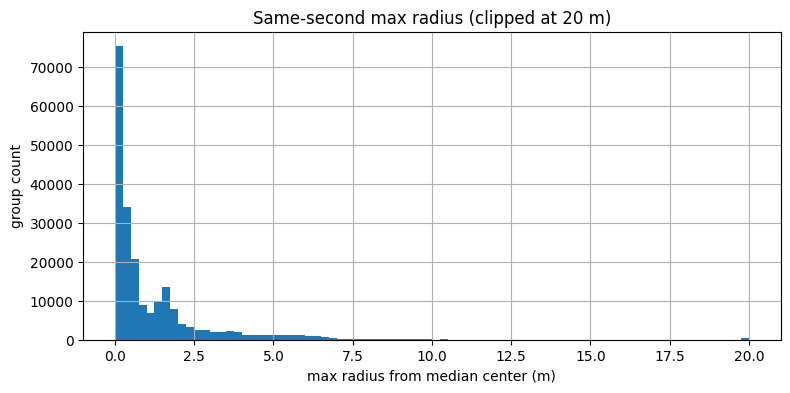

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
same_second["max_radius_m"].clip(upper=20).hist(bins=80, ax=ax)
ax.set(
    title="Same-second max radius (clipped at 20 m)",
    xlabel="max radius from median center (m)",
    ylabel="group count",
)
plt.show()

### Kết luận phần 5

Đã đo **212,409 same-second groups**. Phần lớn các observations cùng timestamp nằm rất gần nhau về không gian:

- median max-radius ≈ **0.47 m**
- p95 ≈ **4.85 m**
- p99 ≈ **7.06 m**
- **99.61%** groups có `max_radius <= 10m`

Trong đó, max_radius là khoảng cách lớn nhất từ các observations trong cùng timestamp tới median location của group.

Điều này cho thấy phần lớn same-second observations có vẻ là các điểm rất gần nhau, phù hợp với GPS jitter / repeated samples, chứ không phải movement thật trong cùng một giây.

Tuy nhiên vẫn tồn tại một tail rất nhỏ có các observations cách nhau hàng trăm km. Những group này không thể được gộp bằng cách lấy trung bình hoặc median rồi coi như một location hợp lệ.

**Candidate rule có evidence:**
* **Trường hợp 1: $\text{max\_radius} \le 10\text{ m}$**
  * Coi cụm điểm là **tương thích không gian** (*spatially compact*).
  * **Giải pháp:** Gộp cụm thành **1 điểm đại diện** (*representative point*) bằng cách lấy tọa độ trung vị (`median(lat)`, `median(lon)`).

* **Trường hợp 2: $\text{max\_radius} > 10\text{ m}$**
  * Coi cụm điểm là **xung đột không gian** (*spatial conflict*).
  * **Giải pháp:** 
    * Tuyệt đối **không tính trung bình** (*no averaging*) các vị trí không tương thích để tránh tạo ra tọa độ ảo.
    * Đánh dấu và tạo **ranh giới gián đoạn** (*continuity boundary* / ngắt chặng quỹ đạo).

# 6. Exact duplicate trajectories và leakage

GeoLife có thể chứa nhiều trajectory files khác nhau nhưng nội dung GPS bên trong lại giống hệt nhau.

Ta hash mỗi raw trajectory file bằng SHA-256 để phát hiện các file có content identity tuyệt đối.

Mục đích của bước này không phải để xóa dữ liệu trong inference pipeline, mà để kiểm tra rủi ro **evaluation leakage**.

Nếu một trajectory xuất hiện ở cả train và test dưới hai file hoặc hai user khác nhau, model có thể được đánh giá trên dữ liệu mà nó thực chất đã thấy trước đó, làm metric bị optimistic một cách giả tạo.

In [13]:
HASH_CACHE = CACHE_DIR / "raw_file_sha256_v1.pkl"

if HASH_CACHE.exists() and not FORCE_REBUILD_HASHES:
    hash_df = pd.read_pickle(HASH_CACHE)
    print("Loaded:", HASH_CACHE)
else:
    rows = []
    for i, (user_id, path) in enumerate(all_files, start=1):
        rows.append({
            "user_id": user_id,
            "trajectory_id": path.stem,
            "path": str(path),
            "sha256": hashlib.sha256(path.read_bytes()).hexdigest(),
        })
        if i % 2000 == 0:
            print(f"{i:,}/{len(all_files):,}")
    hash_df = pd.DataFrame(rows)
    atomic_pickle_write(hash_df, HASH_CACHE)

hash_groups = (
    hash_df.groupby("sha256")
    .agg(
        file_count=("sha256", "size"),
        user_count=("user_id", "nunique"),
        users=("user_id", lambda x: sorted(set(x))),
    )
    .reset_index()
)

duplicate_hashes = hash_groups[hash_groups["file_count"] > 1].copy()
cross_user_hashes = duplicate_hashes[duplicate_hashes["user_count"] > 1].copy()

dup_files = hash_df[hash_df["sha256"].isin(cross_user_hashes["sha256"])].copy()
dup_files = dup_files.merge(
    traj[["user_id", "trajectory_id", "n_points"]],
    on=["user_id", "trajectory_id"],
    how="left",
)

print("Exact duplicate hash groups:", f"{len(duplicate_hashes):,}")
print("Cross-user duplicate groups:", f"{len(cross_user_hashes):,}")
print("Files participating:", f"{len(dup_files):,}", f"({len(dup_files)/len(all_files):.2%})")
print("Points in duplicate files:", f"{int(dup_files['n_points'].sum()):,}", f"({dup_files['n_points'].sum()/total_points:.2%})")

Loaded: /mnt/geolife-data/eda_cache/raw_file_sha256_v1.pkl
Exact duplicate hash groups: 821
Cross-user duplicate groups: 821
Files participating: 1,677 (8.98%)
Points in duplicate files: 2,965,977 (11.92%)


* **Hiện tượng:** Có **821 nhóm file** trùng khớp chính xác 100% nội dung (cùng mã băm SHA-256). Đáng chú ý, toàn bộ 821 nhóm này đều là **trùng lặp chéo giữa các user khác nhau** (*cross-user duplicates*).
* **Quy mô ảnh hưởng:** 
  * Chiếm **1,677 files** (~**8.98%** tổng số file trajectory).
  * Chiếm **~2.97 triệu điểm GPS** (~**11.92%** tổng lượng dữ liệu của toàn bộ dataset).

In [14]:
hash_points = hash_df.merge(
    traj[["user_id", "trajectory_id", "n_points"]],
    on=["user_id", "trajectory_id"],
    how="left",
)

dup_point_groups = (
    hash_points.groupby("sha256")
    .agg(
        file_count=("sha256", "size"),
        user_count=("user_id", "nunique"),
        total_points=("n_points", "sum"),
        representative_points=("n_points", "first"),
    )
    .reset_index()
)

dup_point_groups = dup_point_groups[dup_point_groups["file_count"] > 1].copy()
dup_point_groups["redundant_points"] = (
    dup_point_groups["total_points"] - dup_point_groups["representative_points"]
)
redundant_points = int(dup_point_groups["redundant_points"].sum())

graph = defaultdict(set)
for row in cross_user_hashes.itertuples(index=False):
    users = row.users
    for i, u in enumerate(users):
        for v in users[i+1:]:
            graph[u].add(v)
            graph[v].add(u)

visited, components = set(), []
for start_user in graph:
    if start_user in visited:
        continue
    stack, comp = [start_user], []
    while stack:
        u = stack.pop()
        if u in visited:
            continue
        visited.add(u)
        comp.append(u)
        stack.extend(graph[u] - visited)
    components.append(sorted(comp))

components = sorted(components, key=len, reverse=True)

print("Redundant points beyond one representative/hash:", f"{redundant_points:,}", f"({redundant_points/total_points:.2%})")
print("Users involved:", len(graph))
print("Connected components:", len(components))
print("Largest component size:", len(components[0]) if components else 0)
display(pd.DataFrame({"component": components[:20], "size": [len(c) for c in components[:20]]}))

Redundant points beyond one representative/hash: 1,495,115 (6.01%)
Users involved: 52
Connected components: 18
Largest component size: 15


,component,size
0,"[056, 078, 082, 101, 109, 110, 112, 115, 126, ...",15
1,"[081, 125, 136]",3
2,"[057, 094, 150]",3
3,"[058, 059, 141]",3
4,"[000, 003]",2
5,"[087, 111]",2
6,"[011, 088]",2
7,"[010, 124]",2
8,"[055, 075]",2
9,"[084, 085]",2


* **Lượng dữ liệu dư thừa thực tế:** Sau khi chỉ giữ lại 1 file đại diện cho mỗi mã hash, có tới **1,495,115 điểm GPS dư thừa tuyệt đối** (~**6.01%** tổng dung lượng toàn bộ dataset) sẽ được loại bỏ mà không làm mất mát bất kỳ thông tin di chuyển nào.
* **Mạng lưới liên đới giữa các User (Connected Components):**
  * Có **52 users** (trên tổng số 182 users) dính dáng vào hiện tượng chia sẻ/trùng lặp file chéo.
  * Phân rã thành **18 cụm liên thông (connected components)** độc lập với nhau.
  * **Cụm lớn nhất (`component 0`):** Gồm **15 users** cùng chia sẻ mạng lưới file trùng lặp (ví dụ: `056`, `078`, `082`, `101`, `109`,...).
* **Hệ quả cho chiến lược chia tập Train / Val / Test:**
  * **Không thể chia Train/Test bằng cách ngẫu nhiên các user** nếu các user đó thuộc cùng một connected component.
  * **Giải pháp bắt buộc (Group-aware split):** Nếu muốn đánh giá mô hình theo kịch bản User-split (Unseen Users), toàn bộ các user trong cùng một `component` **phải cùng nằm trọn vẹn ở 1 tập duy nhất** (hoặc toàn bộ ở Train, hoặc toàn bộ ở Test) để triệt tiêu hoàn toàn rủi ro rò rỉ dữ liệu (data leakage).

### Duplicate structure và rủi ro leakage

Exact-duplicate analysis cho thấy đây không phải hiện tượng hiếm:

- **1,495,115 GPS points** là redundant content nếu mỗi SHA-256 hash chỉ giữ một representative (~**6.01%** toàn dataset).
- **52 / 182 users** có liên quan tới exact-duplicate trajectories.
- Các users này tạo thành **18 connected components**; component lớn nhất có **15 users**.

Điều này tạo rủi ro train/test leakage: cùng một GPS trajectory có thể xuất hiện dưới các file hoặc `user_id` khác nhau.

Vì vậy khi evaluation:
- các trajectories có cùng content hash phải nằm trong cùng một split;
- với unseen-user evaluation nghiêm ngặt hơn, có thể group theo connected component để tránh shared content crossing Train/Test.

### Kết luận phần 6

Exact duplicate trajectories xuất hiện đủ nhiều và trải qua nhiều `user_id`, nên split ngẫu nhiên theo file hoặc chỉ theo user có thể tạo **train/test leakage**.

**Quyết định:** dùng SHA-256 content hash làm grouping key khi evaluation. Với unseen-user evaluation, component-aware split là phương án nghiêm ngặt hơn.

Đây là vấn đề của **evaluation design**, không phải cleaning rule cho inference.

# 7. Gộp same-second observations và kiểm tra tác động trên toàn dataset

Ở phần trước, ta đã thấy phần lớn các observations có cùng timestamp nằm rất gần nhau về không gian.

Vì vậy ta thử một preprocessing rule để biến mỗi timestamp thành tối đa một observation:

1. kiểm tra coordinate hợp lệ;
2. gom các rows có cùng exact timestamp;
3. lấy median latitude / longitude làm vị trí đại diện;
4. nếu toàn bộ group nằm trong phạm vi `10 m` quanh median → giữ một representative point;
5. nếu group trải rộng hơn `10 m` → coi là spatial conflict, không cố tạo một vị trí giả ở giữa và tạo continuity boundary.

In [15]:
def consolidate_same_second(
    df: pd.DataFrame,
    radius_threshold_m: float = 10.0,
) -> tuple[pd.DataFrame, dict]:
    work = df.copy()

    valid_coord = (
        work["latitude"].between(-90, 90)
        & work["longitude"].between(-180, 180)
    )
    invalid_coord_count = int((~valid_coord).sum())
    work = work.loc[valid_coord].copy()

    work["center_lat"] = work.groupby("timestamp")["latitude"].transform("median")
    work["center_lon"] = work.groupby("timestamp")["longitude"].transform("median")
    work["radius_m"] = haversine_vectorized(
        work["center_lat"].to_numpy(),
        work["center_lon"].to_numpy(),
        work["latitude"].to_numpy(),
        work["longitude"].to_numpy(),
    )

    consolidated = (
        work.groupby("timestamp", sort=True, as_index=False)
        .agg(
            latitude=("latitude", "median"),
            longitude=("longitude", "median"),
            raw_point_count=("timestamp", "size"),
            max_radius_m=("radius_m", "max"),
        )
    )

    consolidated["spatial_conflict"] = (
        consolidated["max_radius_m"] > radius_threshold_m
    )
    consolidated.loc[
        consolidated["spatial_conflict"],
        ["latitude", "longitude"],
    ] = np.nan

    stats = {
        "raw_points": len(df),
        "invalid_coord_points": invalid_coord_count,
        "consolidated_rows": len(consolidated),
        "compact_rows": int((~consolidated["spatial_conflict"]).sum()),
        "conflict_rows": int(consolidated["spatial_conflict"].sum()),
    }
    return consolidated, stats

def consolidated_segments(df: pd.DataFrame) -> pd.DataFrame:
    x = df.sort_values("timestamp").copy()
    x["dt_s"] = x["timestamp"].diff().dt.total_seconds()
    x["prev_lat"] = x["latitude"].shift(1)
    x["prev_lon"] = x["longitude"].shift(1)
    x["distance_m"] = haversine_vectorized(
        x["prev_lat"], x["prev_lon"], x["latitude"], x["longitude"]
    )
    valid = (
        x["dt_s"].gt(0)
        & x["latitude"].notna()
        & x["longitude"].notna()
        & x["prev_lat"].notna()
        & x["prev_lon"].notna()
    )
    x["speed_kmh"] = np.nan
    x.loc[valid, "speed_kmh"] = x.loc[valid, "distance_m"] / x.loc[valid, "dt_s"] * 3.6
    return x

In [16]:
# Hai case study đã audit
case_141 = read_plt(file_map[("141", "20111022031803")])
case_062 = read_plt(file_map[("062", "20080926000623")])

clean_141, stats_141 = consolidate_same_second(case_141, 10.0)
clean_062, stats_062 = consolidate_same_second(case_062, 10.0)

print("user 141:", stats_141)
print("user 062:", stats_062)

display(
    consolidated_segments(clean_062)[
        ["timestamp", "dt_s", "distance_m", "speed_kmh"]
    ].sort_values("speed_kmh", ascending=False).head(10)
)

user 141: {'raw_points': 56780, 'invalid_coord_points': 0, 'consolidated_rows': 11565, 'compact_rows': 11562, 'conflict_rows': 3}
user 062: {'raw_points': 8117, 'invalid_coord_points': 0, 'consolidated_rows': 8091, 'compact_rows': 8065, 'conflict_rows': 26}


,timestamp,dt_s,distance_m,speed_kmh
7222,2008-09-26 09:22:46+00:00,1.0,861630.211864,3.101869e+06
7224,2008-09-26 09:22:52+00:00,1.0,861530.059231,3.101508e+06
7226,2008-09-26 09:22:57+00:00,1.0,861493.780549,3.101378e+06
7228,2008-09-26 09:23:02+00:00,1.0,861454.301916,3.101235e+06
7230,2008-09-26 09:23:07+00:00,1.0,861404.878331,3.101058e+06
7232,2008-09-26 09:23:12+00:00,1.0,861350.288731,3.100861e+06
7234,2008-09-26 09:23:17+00:00,1.0,861292.172534,3.100652e+06
7236,2008-09-26 09:23:22+00:00,1.0,861233.112364,3.100439e+06
7240,2008-09-26 09:23:32+00:00,1.0,861105.919093,3.099981e+06
7242,2008-09-26 09:23:37+00:00,1.0,861039.555980,3.099742e+06


Case Study Tái Lập & Kiểm Định Độc Lập

* **User 141 (Xử lý trùng lặp giây thành công):**
  * **56,780 raw points → 11,565 unique timestamps** (thu gọn ~80% số dòng dư thừa).
  * 11,562 điểm đạt chuẩn gọn không gian ($\le 10\text{ m}$), chỉ có 3 điểm bị xung đột được gán `NaN` làm ranh giới an toàn.
* **User 062 (Vấn đề không nằm ở trùng giây):**
  * **8,117 raw points → 8,091 unique timestamps** (chỉ giảm nhẹ 26 dòng).
  * Vẫn giữ nguyên các bước nhảy bất thường hàng triệu km/h ($> 3.1 \times 10^6\text{ km/h}$, nhảy $\approx 861\text{ km}$ trong đúng $1.0\text{ s}$).
  * **Nguyên nhân:** Lỗi này xảy ra giữa **các mốc thời gian khác nhau** (*different timestamps*), nằm ngoài phạm vi xử lý của hàm gom cụm cùng giây.

> **Kết luận then chốt:**  
> **Same-second ambiguity** (nhiễu/trùng lặp trong cùng một giây) và **inter-timestamp corruption** (bước nhảy tọa độ phi vật lý giữa các giây khác nhau) là **hai vấn đề chất lượng dữ liệu hoàn toàn độc lập**.  
> Pipeline làm sạch dữ liệu bắt buộc phải kết hợp cả 2 lớp xử lý: (1) Gom cụm/lọc trùng giây và (2) Lọc vận tốc/tách chặng quỹ đạo (*speed-based segmentation*).

In [17]:
SPEED_THRESHOLDS = [50, 100, 150, 200, 300, 500, 1000]

def summarize_consolidated_trajectory(user_id, path, radius_threshold_m=10.0):
    raw = read_plt(path)
    consolidated, stats = consolidate_same_second(raw, radius_threshold_m)
    x = consolidated.sort_values("timestamp").copy()

    dt_s = x["timestamp"].diff().dt.total_seconds().to_numpy()
    lat = x["latitude"].to_numpy()
    lon = x["longitude"].to_numpy()

    distance_m = np.full(len(x), np.nan)
    if len(x) > 1:
        distance_m[1:] = haversine_vectorized(lat[:-1], lon[:-1], lat[1:], lon[1:])

    prev_valid = np.r_[False, np.isfinite(lat[:-1]) & np.isfinite(lon[:-1])]
    curr_valid = np.isfinite(lat) & np.isfinite(lon)
    valid_segment = (
        np.isfinite(dt_s)
        & (dt_s > 0)
        & prev_valid
        & curr_valid
        & np.isfinite(distance_m)
    )

    speed_kmh = np.full(len(x), np.nan)
    speed_kmh[valid_segment] = distance_m[valid_segment] / dt_s[valid_segment] * 3.6

    valid_speeds = speed_kmh[np.isfinite(speed_kmh)]
    positive_dt = dt_s[np.isfinite(dt_s) & (dt_s > 0)]

    result = {
        "user_id": user_id,
        "trajectory_id": path.stem,
        "raw_points": len(raw),
        "consolidated_rows": len(x),
        "invalid_coord_points": stats["invalid_coord_points"],
        "conflict_rows": stats["conflict_rows"],
        "duration_min": (
            (x["timestamp"].max() - x["timestamp"].min()).total_seconds() / 60
            if len(x) >= 2 else 0.0
        ),
        "valid_segments": int(valid_segment.sum()),
        "distance_km": np.nansum(distance_m[valid_segment]) / 1000,
        "median_gap_s": float(np.median(positive_dt)) if len(positive_dt) else np.nan,
        "p95_gap_s": float(np.percentile(positive_dt, 95)) if len(positive_dt) else np.nan,
        "max_gap_s": float(np.max(positive_dt)) if len(positive_dt) else np.nan,
        "max_speed_kmh": float(np.max(valid_speeds)) if len(valid_speeds) else np.nan,
        "p99_speed_kmh": float(np.percentile(valid_speeds, 99)) if len(valid_speeds) else np.nan,
    }

    for threshold in SPEED_THRESHOLDS:
        result[f"segments_gt_{threshold}"] = int((valid_speeds > threshold).sum())

    return result

In [18]:
CONSOLIDATION_VERSION = "v1_r10m"
CLEAN_CACHE = CACHE_DIR / f"consolidated_summary_{CONSOLIDATION_VERSION}.pkl"
CLEAN_PARTIAL = CACHE_DIR / f"consolidated_summary_{CONSOLIDATION_VERSION}.partial.pkl"

if CLEAN_CACHE.exists() and not FORCE_REBUILD_CONSOLIDATED:
    clean_traj = pd.read_pickle(CLEAN_CACHE)
    print("Loaded:", CLEAN_CACHE)
else:
    if FORCE_REBUILD_CONSOLIDATED:
        CLEAN_PARTIAL.unlink(missing_ok=True)

    if CLEAN_PARTIAL.exists():
        partial = pd.read_pickle(CLEAN_PARTIAL)
        rows = partial.to_dict("records")
        done = set(zip(partial["user_id"], partial["trajectory_id"]))
        print(f"Resume: {len(done):,}/{len(all_files):,}")
    else:
        rows, done = [], set()

    start = perf_counter()
    newly_processed = 0

    for user_id, path in all_files:
        key = (user_id, path.stem)
        if key in done:
            continue

        rows.append(summarize_consolidated_trajectory(user_id, path, 10.0))
        done.add(key)
        newly_processed += 1

        if newly_processed % 500 == 0:
            atomic_pickle_write(pd.DataFrame(rows), CLEAN_PARTIAL)
            elapsed = perf_counter() - start
            rate = newly_processed / elapsed
            remaining = len(all_files) - len(done)
            print(
                f"{len(done):,}/{len(all_files):,} | "
                f"{rate:.1f} files/s | ETA ~{remaining / rate / 60:.1f} min"
            )

    clean_traj = pd.DataFrame(rows)
    atomic_pickle_write(clean_traj, CLEAN_CACHE)
    CLEAN_PARTIAL.unlink(missing_ok=True)
    print("Saved:", CLEAN_CACHE)

Loaded: /mnt/geolife-data/eda_cache/consolidated_summary_v1_r10m.pkl


In [19]:
raw_points = int(clean_traj["raw_points"].sum())
consolidated_rows = int(clean_traj["consolidated_rows"].sum())
conflict_rows = int(clean_traj["conflict_rows"].sum())
invalid_points = int(clean_traj["invalid_coord_points"].sum())
total_valid_segments = int(clean_traj["valid_segments"].sum())

print("Raw points:", f"{raw_points:,}")
print("Consolidated rows:", f"{consolidated_rows:,}")
print("Rows reduced:", f"{raw_points - consolidated_rows:,}", f"({1 - consolidated_rows/raw_points:.2%})")
print("Spatial-conflict timestamps:", f"{conflict_rows:,}", f"({conflict_rows/consolidated_rows:.4%})")
print("Invalid coordinate points:", invalid_points)
print("Valid movement segments:", f"{total_valid_segments:,}")

segment_speed_rows = []
for threshold in SPEED_THRESHOLDS:
    count = int(clean_traj[f"segments_gt_{threshold}"].sum())
    segment_speed_rows.append({
        "threshold_kmh": threshold,
        "segments": count,
        "share": count / total_valid_segments,
    })

segment_speed_summary = pd.DataFrame(segment_speed_rows)
display(segment_speed_summary)

Raw points: 24,876,978
Consolidated rows: 24,178,077
Rows reduced: 698,901 (2.81%)
Spatial-conflict timestamps: 835 (0.0035%)
Invalid coordinate points: 1
Valid movement segments: 24,157,908


,threshold_kmh,segments,share
0,50,5259160,0.217699
1,100,1305237,0.054029
2,150,241167,0.009983
3,200,88450,0.003661
4,300,53379,0.002210
5,500,49035,0.002030
6,1000,1691,0.000070


### Kết luận phần 7

Khi áp dụng same-second consolidation trên toàn bộ release:

- 24,876,978 raw points → 24,178,077 timestamp-level observations
- giảm 698,901 rows (~2.81%)
- chỉ có 835 timestamps bị spatial conflict
- phát hiện 1 invalid coordinate
- còn 24,157,908 valid inter-timestamp movement segments

Kết quả cho thấy rule consolidation xử lý được phần lớn vấn đề duplicate timestamp với mức mất thông tin rất thấp: đa số same-second groups có thể gộp an toàn thành một representative point, trong khi chỉ một phần rất nhỏ bị đánh dấu spatial conflict.

Tuy nhiên, consolidation chỉ giải quyết zero-time / same-second ambiguity. Các impossible jumps xảy ra giữa hai timestamp khác nhau vẫn còn tồn tại, nên residual high-speed corruption phải được xử lý ở một stage riêng.

**Quyết định**: giữ same-second consolidation như một preprocessing stage độc lập; sau đó mới phân tích temporal gaps và movement-speed anomalies.

# 8. Kiểm tra tốc độ bất thường và khoảng trống thời gian giữa các GPS points

Một trajectory có thể chứa hàng nghìn movement segments. Nếu chỉ nhìn `max_speed` của cả trajectory, chỉ cần **một segment lỗi** là toàn bộ trajectory trông bất thường.

Vì vậy ở phần này ta:

1. đo speed ở **từng segment** để biết high-speed anomaly thực sự phổ biến đến mức nào;
2. đo **time gap** giữa các observations liên tiếp để kiểm tra khi nào trajectory không còn đủ bằng chứng về chuyển động liên tục.

Hai vấn đề này được phân tích riêng:
- **speed anomaly**: đoạn nối giữa hai observations có hợp lý không?
- **temporal gap**: hai observations có cách nhau quá lâu để coi là cùng một chuỗi liên tục không?

In [20]:
display(
    clean_traj[
        [
            "consolidated_rows",
            "duration_min",
            "distance_km",
            "median_gap_s",
            "p95_gap_s",
            "max_gap_s",
            "max_speed_kmh",
            "p99_speed_kmh",
        ]
    ].describe(percentiles=[.01, .05, .25, .5, .75, .9, .95, .99])
)

for threshold in SPEED_THRESHOLDS:
    seg_count = int(clean_traj[f"segments_gt_{threshold}"].sum())
    traj_count = int((clean_traj["max_speed_kmh"] > threshold).sum())
    print(
        f">{threshold:4d} km/h | "
        f"segments={seg_count:10,d} ({seg_count/total_valid_segments:.4%}) | "
        f"trajectories={traj_count:5d} ({traj_count/len(clean_traj):.2%})"
    )

,consolidated_rows,duration_min,distance_km,median_gap_s,p95_gap_s,max_gap_s,max_speed_kmh,p99_speed_kmh
count,18670.000000,18670.000000,18670.000000,18670.000000,18670.000000,18670.000000,1.866900e+04,1.866900e+04
mean,1295.022871,161.253701,65.718470,5.971505,34.483315,2925.128548,4.142220e+02,1.553910e+02
std,2683.979781,259.992307,3739.636424,110.651879,475.933032,5278.920900,2.436623e+04,1.136302e+04
min,2.000000,0.033333,0.000000,1.000000,1.000000,1.000000,0.000000e+00,0.000000e+00
1%,6.000000,0.500000,0.050045,1.000000,1.000000,2.000000,9.020680e+00,8.415369e+00
5%,28.000000,3.733333,0.475247,1.000000,2.000000,5.000000,2.213075e+01,1.660767e+01
25%,200.000000,16.833333,2.766046,2.000000,3.000000,64.000000,6.189530e+01,3.930654e+01
50%,504.000000,42.133333,10.032168,2.000000,5.000000,325.000000,9.480171e+01,5.866917e+01
75%,1339.750000,192.429167,22.403157,5.000000,6.000000,2903.750000,1.663478e+02,7.930596e+01
90%,3239.100000,530.413333,51.547554,5.000000,25.665000,11010.400000,2.688454e+02,1.046860e+02


>  50 km/h | segments= 5,259,160 (21.7699%) | trajectories=15457 (82.79%)
> 100 km/h | segments= 1,305,237 (5.4029%) | trajectories= 8767 (46.96%)
> 150 km/h | segments=   241,167 (0.9983%) | trajectories= 5348 (28.64%)
> 200 km/h | segments=    88,450 (0.3661%) | trajectories= 3490 (18.69%)
> 300 km/h | segments=    53,379 (0.2210%) | trajectories= 1596 (8.55%)
> 500 km/h | segments=    49,035 (0.2030%) | trajectories=  790 (4.23%)
>1000 km/h | segments=     1,691 (0.0070%) | trajectories=  268 (1.44%)


* **Tần suất phân đoạn cực đoan (Segment-level):**
  * Tỷ lệ các phân đoạn có tốc độ phi lý rất nhỏ trên toàn bộ tập dữ liệu: chỉ **0.998%** phân đoạn $> 150\text{ km/h}$, **0.22%** $> 300\text{ km/h}$ (ngưỡng tàu cao tốc), và **0.007%** $> 1,000\text{ km/h}$ (vận tốc máy bay/siêu thanh).
* **Mức độ ảnh hưởng diện rộng lên quỹ đạo (Trajectory-level):**
  * Tuy số phân đoạn lỗi rất ít, nhưng chúng **rải rác trên diện rộng**:
    * **28.64% trajectories** (5,348 files) có ít nhất 1 phân đoạn $> 150\text{ km/h}$.
    * **8.55% trajectories** (1,596 files) có ít nhất 1 phân đoạn $> 300\text{ km/h}$.
    * **1.44% trajectories** (268 files) văng tốc độ phi vật lý $> 1,000\text{ km/h}$.

,threshold_s,threshold_min,trajectories,share
0,30,0.5,15281,0.818479
1,60,1.0,14158,0.758329
2,120,2.0,12308,0.659239
3,300,5.0,9513,0.509534
4,600,10.0,7793,0.417408
5,1800,30.0,5537,0.296572
6,3600,60.0,4274,0.228923
7,7200,120.0,2962,0.158650
8,14400,240.0,1172,0.062775


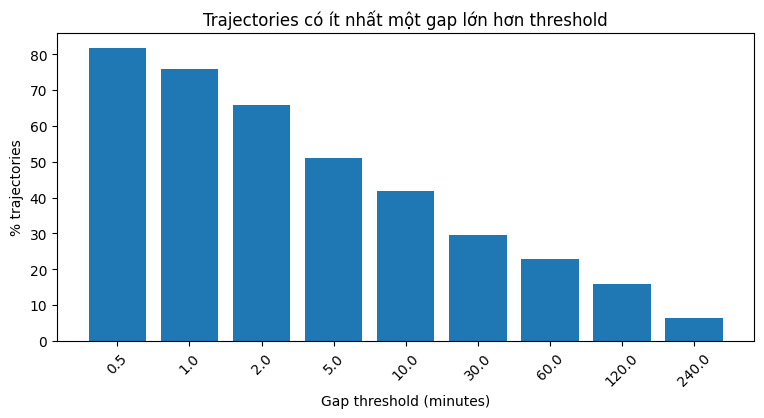

In [21]:
gap_thresholds = [30, 60, 120, 300, 600, 1800, 3600, 7200, 14400]
gap_rows = []

for threshold in gap_thresholds:
    count = int((clean_traj["max_gap_s"] > threshold).sum())
    gap_rows.append({
        "threshold_s": threshold,
        "threshold_min": threshold / 60,
        "trajectories": count,
        "share": count / len(clean_traj),
    })

gap_summary = pd.DataFrame(gap_rows)
display(gap_summary)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(gap_summary["threshold_min"].astype(str), gap_summary["share"] * 100)
ax.set(
    title="Trajectories có ít nhất một gap lớn hơn threshold",
    xlabel="Gap threshold (minutes)",
    ylabel="% trajectories",
)
plt.xticks(rotation=45)
plt.show()

### Kết luận phần 8

Sau same-second consolidation, high-speed anomaly vẫn còn nhưng mức độ nhìn rất khác giữa **segment-level** và **trajectory-level**:

- `>100 km/h`: khoảng **5.40% segments**, nhưng gần **46.96% trajectories** có ít nhất một segment vượt ngưỡng;
- `>200 km/h`: khoảng **0.37% segments**;
- `>500 km/h`: khoảng **0.20% segments**;
- `>1000 km/h`: khoảng **0.007% segments**.

Điều này cho thấy `trajectory max_speed` dễ làm vấn đề trông nghiêm trọng hơn thực tế: chỉ cần một bad segment là cả trajectory bị đánh dấu.

Temporal gaps cũng phổ biến:

- `>2 min`: ~**65.92% trajectories**
- `>5 min`: ~**50.95%**
- `>10 min`: ~**41.74%**
- `>30 min`: ~**29.66%**

Một time gap dài không nhất thiết là GPS error, nhưng nó làm mất bằng chứng rằng hai observations ở hai phía thuộc cùng một chuyển động liên tục.

**Quyết định:**

- đặt một ngưỡng `max_gap_s` để xác định khi nào khoảng cách thời gian giữa hai GPS points là quá lớn và không nên coi chúng là một chuyển động liên tục;
- khi có khoảng trống thời gian dài, không được cộng thời gian ở hai phía lại để tạo thành một stay dài giả;
- kiểm tra **tốc độ bất thường** và **khoảng trống thời gian** như hai loại vấn đề riêng;
- chưa chọn ngưỡng tốc độ cố định chỉ từ distribution hiện tại, vì tốc độ cao có thể vẫn hợp lý với một số phương tiện như máy bay hoặc tàu. Cần dùng transportation labels để kiểm tra thêm.

# 9. Kiểm tra transportation labels trước khi dùng để đánh giá speed

Transportation labels được dùng để trả lời một câu hỏi:

> Những mức speed cao nào vẫn có thể hợp lý với một phương tiện thật, và mức nào có dấu hiệu corruption?

Các labels này **không phải Home/Office ground truth**.

Trước khi dùng labels để benchmark speed, cần kiểm tra cách hiểu khoảng thời gian của từng label.

### Cách xác định transportation mode theo thời gian

Mỗi transportation label cho biết một mode có hiệu lực trong một khoảng thời gian.

Ví dụ:

- Bus: `[09:00, 10:00)`
- Walk: `[10:00, 10:30)`

Ta dùng quy ước **half-open interval `[start, end)`**:
`start` được tính vào interval, còn `end` thì không.

Vì vậy tại đúng `10:00`, label Bus đã kết thúc và label Walk bắt đầu.
Hai intervals chỉ nối tiếp nhau, **không conflict**.

Ngược lại, nếu:

- Bus: `[09:00, 10:05)`
- Walk: `[10:00, 10:30)`

thì khoảng `10:00–10:05` được gán cho hai mode khác nhau cùng lúc.
Đây là **true overlap**, nên transportation mode trong khoảng đó bị ambiguous.

Việc phân biệt hai trường hợp này cần thiết trước khi dùng transportation labels để benchmark speed theo từng mode.

In [22]:
label_users = inventory.loc[inventory["has_labels"], "user_id"].tolist()
label_frames = []

for user_id in label_users:
    label_frames.append(
        read_labels(DATA_ROOT / user_id / "labels.txt", user_id)
    )

labels_all = pd.concat(label_frames, ignore_index=True)

print("Labeled users:", len(label_users))
print("Label intervals:", f"{len(labels_all):,}")
display(labels_all["mode"].value_counts())

Labeled users: 69
Label intervals: 14,718


mode
walk          6460
bus           2853
bike          2089
taxi          1179
car            993
subway         813
train          299
airplane        17
boat             7
run              6
motorcycle       2
Name: count, dtype: int64

In [23]:
def count_cross_mode_relationships(labels: pd.DataFrame):
    endpoint_touching = 0
    true_overlap = 0
    examples_touch = []
    examples_overlap = []

    for user_id, g in labels.groupby("user_id"):
        g = g.sort_values(["start_time", "end_time"]).reset_index(drop=True)

        for i in range(len(g)):
            a = g.iloc[i]
            for j in range(i + 1, len(g)):
                b = g.iloc[j]

                # Vì đã sort theo start_time, nếu b bắt đầu sau a.end thì
                # không thể touch/overlap với a hoặc các row sau nữa.
                if b["start_time"] > a["end_time"]:
                    break

                if a["mode"] == b["mode"]:
                    continue

                if b["start_time"] == a["end_time"]:
                    endpoint_touching += 1
                    if len(examples_touch) < 10:
                        examples_touch.append(
                            (user_id, a["mode"], b["mode"], a["end_time"])
                        )
                elif b["start_time"] < a["end_time"]:
                    # half-open [start,end): positive-duration overlap
                    overlap_start = max(a["start_time"], b["start_time"])
                    overlap_end = min(a["end_time"], b["end_time"])
                    if overlap_start < overlap_end:
                        true_overlap += 1
                        if len(examples_overlap) < 10:
                            examples_overlap.append(
                                (user_id, a["mode"], b["mode"], overlap_start, overlap_end)
                            )

    return endpoint_touching, true_overlap, examples_touch, examples_overlap

endpoint_touching_pairs, true_overlap_pairs, touch_examples, overlap_examples = (
    count_cross_mode_relationships(labels_all)
)

print("Different-mode endpoint-touching pairs:", endpoint_touching_pairs)
print("Different-mode true-overlap pairs:", true_overlap_pairs)
display(pd.DataFrame(touch_examples, columns=["user_id", "mode_a", "mode_b", "touch_time"]))
display(pd.DataFrame(overlap_examples, columns=["user_id", "mode_a", "mode_b", "overlap_start", "overlap_end"]))

Different-mode endpoint-touching pairs: 1742
Different-mode true-overlap pairs: 146


,user_id,mode_a,mode_b,touch_time
0,052,bus,walk,2008-05-20 12:25:00+00:00
1,052,walk,taxi,2008-05-20 14:15:00+00:00
2,052,bus,walk,2008-05-21 03:35:00+00:00
3,052,bus,subway,2008-05-21 10:36:00+00:00
4,052,subway,walk,2008-05-21 11:25:00+00:00
5,052,walk,bus,2008-05-21 12:35:00+00:00
6,052,bus,walk,2008-05-21 12:38:00+00:00
7,052,walk,bus,2008-05-21 13:50:00+00:00
8,052,bus,walk,2008-05-22 09:10:50+00:00
9,052,walk,bus,2008-05-22 10:00:00+00:00


,user_id,mode_a,mode_b,overlap_start,overlap_end
0,020,bus,walk,2011-09-05 14:40:29+00:00,2011-09-05 14:41:56+00:00
1,020,bus,walk,2011-09-06 01:51:18+00:00,2011-09-06 01:51:25+00:00
2,020,walk,bus,2011-09-10 15:00:56+00:00,2011-09-10 15:13:43+00:00
3,020,walk,subway,2011-09-11 00:05:06+00:00,2011-09-11 00:14:44+00:00
4,020,subway,walk,2011-09-11 00:32:48+00:00,2011-09-11 02:53:35+00:00
5,020,subway,train,2011-09-11 02:53:36+00:00,2011-09-11 04:13:07+00:00
6,020,subway,walk,2011-09-11 04:13:08+00:00,2011-09-11 08:38:19+00:00
7,020,subway,car,2011-09-11 08:38:20+00:00,2011-09-11 10:26:49+00:00
8,020,subway,walk,2011-09-11 10:26:50+00:00,2011-09-11 10:49:02+00:00
9,020,walk,bus,2011-09-12 06:29:43+00:00,2011-09-12 06:31:50+00:00


* **Phân tích kết quả:**
  * **1,742 cặp Endpoint-Touching (Bình thường):** Đây là hành vi chuyển đổi phương tiện thực tế (chuyển tuyến/transfer), ví dụ: vừa xuống xe buýt lúc 12:25:00 là bắt đầu đi bộ ngay lúc 12:25:00 (`bus -> walk`, `subway -> walk`).
  * **146 cặp True-Overlap (Bất thường / Xung đột nhãn):** Cùng một khoảng thời gian người dùng vừa được gán là `bus` vừa là `walk`, hoặc cả `subway` lẫn `train`.

In [24]:
def canonicalize_user_labels_half_open(user_labels: pd.DataFrame):
    user_labels = user_labels.sort_values(["start_time", "end_time"]).copy()

    if user_labels.empty:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    user_id = user_labels["user_id"].iloc[0]
    events = defaultdict(Counter)

    for row in user_labels.itertuples(index=False):
        events[row.start_time][row.mode] += 1
        events[row.end_time][row.mode] -= 1   # half-open [start, end)

    times = sorted(events)
    active = Counter()
    safe_rows, ambiguous_atomic_rows = [], []

    for i, start in enumerate(times[:-1]):
        # Apply all starts/ends at this boundary before evaluating [start, next_time).
        for mode, delta in events[start].items():
            active[mode] += delta
            if active[mode] <= 0:
                del active[mode]

        end = times[i + 1]
        if end <= start:
            continue

        active_modes = tuple(sorted(active.keys()))

        if len(active_modes) == 1:
            safe_rows.append({
                "user_id": user_id,
                "start_time": start,
                "end_time": end,          # exclusive
                "mode": active_modes[0],
            })
        elif len(active_modes) > 1:
            # Atomic event-sweep slice. Adjacent slices may still belong to one
            # maximal ambiguous time window if an event changes the active mode set.
            ambiguous_atomic_rows.append({
                "user_id": user_id,
                "start_time": start,
                "end_time": end,          # exclusive
                "modes": active_modes,
            })

    safe = pd.DataFrame(safe_rows)
    ambiguous_atomic = pd.DataFrame(ambiguous_atomic_rows)

    # Merge contiguous safe windows of the same mode.
    if not safe.empty:
        merged_safe = []
        for row in safe.to_dict("records"):
            if (
                merged_safe
                and row["mode"] == merged_safe[-1]["mode"]
                and row["start_time"] == merged_safe[-1]["end_time"]
            ):
                merged_safe[-1]["end_time"] = row["end_time"]
            else:
                merged_safe.append(row)
        safe = pd.DataFrame(merged_safe)

    # Merge adjacent atomic slices only when the active DISTINCT mode set
    # is unchanged. If the set changes (e.g. bus+walk -> bus+train), keep a
    # new ambiguous window even though ambiguity is temporally continuous.
    # This makes a "window" mean one stable active-mode combination.
    if not ambiguous_atomic.empty:
        merged_ambiguous = []
        for row in ambiguous_atomic.sort_values(
            ["start_time", "end_time"]
        ).to_dict("records"):
            if (
                merged_ambiguous
                and row["start_time"] == merged_ambiguous[-1]["end_time"]
                and tuple(row["modes"]) == tuple(merged_ambiguous[-1]["modes"])
            ):
                merged_ambiguous[-1]["end_time"] = row["end_time"]
                merged_ambiguous[-1]["atomic_slices"] += 1
            else:
                merged_ambiguous.append({
                    **row,
                    "atomic_slices": 1,
                })
        ambiguous = pd.DataFrame(merged_ambiguous)
    else:
        ambiguous = pd.DataFrame()

    return safe, ambiguous_atomic, ambiguous


canonical_parts = []
ambiguous_atomic_parts = []
ambiguous_parts = []

for user_id, user_labels in labels_all.groupby("user_id"):
    safe, ambiguous_atomic, ambiguous = canonicalize_user_labels_half_open(
        user_labels
    )
    if not safe.empty:
        canonical_parts.append(safe)
    if not ambiguous_atomic.empty:
        ambiguous_atomic_parts.append(ambiguous_atomic)
    if not ambiguous.empty:
        ambiguous_parts.append(ambiguous)

canonical_labels = pd.concat(canonical_parts, ignore_index=True)
ambiguous_atomic_labels = pd.concat(
    ambiguous_atomic_parts, ignore_index=True
)
ambiguous_labels = pd.concat(ambiguous_parts, ignore_index=True)

canonical_seconds = (
    canonical_labels["end_time"] - canonical_labels["start_time"]
).dt.total_seconds().sum()

ambiguous_seconds = (
    ambiguous_labels["end_time"] - ambiguous_labels["start_time"]
).dt.total_seconds().sum()

covered_seconds = canonical_seconds + ambiguous_seconds

print("Canonical unambiguous windows:", f"{len(canonical_labels):,}")
print("Ambiguous atomic sweep slices:", f"{len(ambiguous_atomic_labels):,}")
print("Ambiguous maximal windows:", f"{len(ambiguous_labels):,}")
print("Unambiguous labeled hours:", f"{canonical_seconds/3600:,.3f}")
print("Ambiguous labeled hours:", f"{ambiguous_seconds/3600:,.3f}")
print("Ambiguous share:", f"{ambiguous_seconds/covered_seconds:.3%}")


Canonical unambiguous windows: 14,583
Ambiguous atomic sweep slices: 149
Ambiguous maximal windows: 138
Unambiguous labeled hours: 12,720.833
Ambiguous labeled hours: 76.345
Ambiguous share: 0.597%


Ví dụ rất đơn giản:

```text
09:00 -------- 10:00 -------- 11:00

BUS  ==========|
WALK            ==============

→ không ambiguity
```

Bus kết thúc lúc Walk bắt đầu. Mỗi thời điểm chỉ có một mode.

Nhưng:

```text
09:00 -------- 10:00 ---- 10:10 -------- 11:00

BUS  ======================|
WALK            ==========================

                   ^^^^^^^
                10:00–10:10
```

Trong `10:00–10:10`, cả `bus` và `walk` cùng active.

Ta không biết GPS segment trong khoảng đó nên mang label `bus` hay `walk`.

→ đây là **ambiguous window**.

---

#### Vậy `149` và `138` khác nhau ở đâu?

Đây là chỗ khó nhất nhưng thực ra `149` chủ yếu là **chi tiết của thuật toán**, còn `138` mới là con số dễ báo cáo.

Giả sử labels phức tạp hơn:

```text
10:00          10:05          10:10

Bus A  ========================
Bus B           =================
Walk   ==========================
```

Thuật toán gặp một event tại `10:05`, nên có thể cắt timeline thành:

```text
10:00–10:05 : bus + walk
10:05–10:10 : bus + walk
```

Về mặt thuật toán, đây là **2 atomic slices** vì có một boundary ở `10:05`.

Nhưng về ý nghĩa transportation mode:

```text
bus + walk
     ↓
bus + walk
```

không có gì thay đổi.

Vậy để report cho con người, ta gộp lại thành:

```text
10:00–10:10 : bus + walk
```

→ **1 ambiguous window**.

Đó là lý do:

```text
149 atomic ambiguous slices
        ↓ gộp những đoạn liền nhau
          nếu tập mode không đổi
138 ambiguous windows
```

Ngược lại nếu:

```text
10:00–10:05 : bus + walk
10:05–10:10 : bus + train
```

thì **không gộp**, vì ambiguity đã đổi bản chất:

```text
{bus, walk} ≠ {bus, train}
```

nên đây là 2 ambiguous windows.

---

và quan trọng hơn nữa là theo **thời lượng**:

```text
12,720.833 giờ rõ mode
76.345 giờ ambiguous
```

tức chỉ khoảng:

```text
76.345
────────────────────────── ≈ 0.597%
12,720.833 + 76.345
```

của labeled time bị ambiguity.

Vậy ý nghĩa cuối cùng cực đơn giản:

> **Khoảng 99.4% thời gian có transportation label là unambiguous; chỉ khoảng 0.6% thời gian có nhiều mode chồng lên nhau.**

Do đó khi benchmark speed theo transportation mode, ta có thể **chỉ sử dụng các khoảng unambiguous và bỏ các khoảng ambiguous khỏi benchmark**.

# 10. Tính lại speed theo từng transportation mode bằng labels đã audit

### Chỉ gán mode khi cả movement segment nằm trọn trong một label window

Một movement segment được tạo bởi hai GPS observations liên tiếp:

`previous point → current point`

Ta chỉ gán transportation mode cho segment đó khi **cả hai đầu của segment đều nằm trong cùng một canonical label window**.

Với window dạng `[start, end)`:

- `prev_timestamp >= start_time`
- `timestamp < end_time`

Ví dụ:

Label `bus = [09:00, 10:00)`

Segment:

`09:40 → 09:45`

→ cả hai endpoints đều nằm trong window  
→ có thể gán `bus`.

Nhưng segment:

`09:59 → 10:01`

→ segment đi xuyên qua boundary của label  
→ không gán mode.

Cách này cố ý conservative để tránh gán sai mode cho các segment nằm sát thời điểm chuyển phương tiện.

In [25]:
files_by_user = defaultdict(list)
for user_id, path in all_files:
    files_by_user[user_id].append(path)

LABEL_V3_DIR = CACHE_DIR / "labeled_segments_half_open_r10m_v3"
LABEL_V3_DIR.mkdir(parents=True, exist_ok=True)

if FORCE_REBUILD_LABEL_V3:
    for p in LABEL_V3_DIR.glob("*.pkl"):
        p.unlink()

def match_segments_to_half_open_labels(user_id, path, user_labels):
    raw = read_plt(path)
    consolidated, _ = consolidate_same_second(raw, 10.0)
    seg = consolidated_segments(consolidated)
    seg = seg[seg["speed_kmh"].notna()].copy()

    if seg.empty or user_labels.empty:
        return pd.DataFrame(columns=[
            "user_id", "trajectory_id", "prev_timestamp", "timestamp",
            "dt_s", "distance_m", "speed_kmh", "mode"
        ])

    seg["prev_timestamp"] = seg["timestamp"] - pd.to_timedelta(seg["dt_s"], unit="s")
    seg["midpoint"] = seg["prev_timestamp"] + (
        seg["timestamp"] - seg["prev_timestamp"]
    ) / 2

    labels = user_labels[
        ["start_time", "end_time", "mode"]
    ].sort_values("start_time")

    matched = pd.merge_asof(
        seg.sort_values("midpoint"),
        labels,
        left_on="midpoint",
        right_on="start_time",
        direction="backward",
    )

    matched = matched[
        matched["start_time"].notna()
        & (matched["prev_timestamp"] >= matched["start_time"])
        & (matched["timestamp"] < matched["end_time"])
    ].copy()

    matched["user_id"] = user_id
    matched["trajectory_id"] = path.stem

    return matched[
        [
            "user_id", "trajectory_id", "prev_timestamp", "timestamp",
            "dt_s", "distance_m", "speed_kmh", "mode"
        ]
    ]

In [26]:
for i, user_id in enumerate(label_users, start=1):
    cache_path = LABEL_V3_DIR / f"{user_id}.pkl"
    if cache_path.exists():
        continue

    user_labels = canonical_labels[
        canonical_labels["user_id"] == user_id
    ].copy()

    parts = []
    for path in files_by_user[user_id]:
        matched = match_segments_to_half_open_labels(user_id, path, user_labels)
        if not matched.empty:
            parts.append(matched)

    result = (
        pd.concat(parts, ignore_index=True)
        if parts
        else pd.DataFrame(columns=[
            "user_id", "trajectory_id", "prev_timestamp", "timestamp",
            "dt_s", "distance_m", "speed_kmh", "mode"
        ])
    )

    atomic_pickle_write(result, cache_path)
    print(f"{i:2d}/{len(label_users)} user {user_id}: {len(result):,} matched segments")

In [27]:
mode_chunks_v3 = defaultdict(list)
matched_segments_v3 = 0

for user_id in label_users:
    df = pd.read_pickle(LABEL_V3_DIR / f"{user_id}.pkl")
    matched_segments_v3 += len(df)

    if df.empty:
        continue

    for mode, group in df.groupby("mode"):
        mode_chunks_v3[mode].append(
            group["speed_kmh"].to_numpy(dtype=np.float32)
        )

valid_segments_label_users = int(
    clean_traj.loc[
        clean_traj["user_id"].isin(label_users),
        "valid_segments",
    ].sum()
)

print("Valid segments in labeled users:", f"{valid_segments_label_users:,}")
print("Matched V3:", f"{matched_segments_v3:,}")
print("Coverage V3:", f"{matched_segments_v3/valid_segments_label_users:.2%}")

interval_counts_v3 = canonical_labels.groupby("mode").size()
user_counts_v3 = canonical_labels.groupby("mode")["user_id"].nunique()

rows = []
for mode, chunks in mode_chunks_v3.items():
    speeds = np.concatenate(chunks)
    rows.append({
        "mode": mode,
        "canonical_windows": int(interval_counts_v3.get(mode, 0)),
        "label_users": int(user_counts_v3.get(mode, 0)),
        "segments": len(speeds),
        "median_kmh": float(np.percentile(speeds, 50)),
        "p95_kmh": float(np.percentile(speeds, 95)),
        "p99_kmh": float(np.percentile(speeds, 99)),
        "max_kmh": float(np.max(speeds)),
        "gt_100": float((speeds > 100).mean()),
        "gt_200": float((speeds > 200).mean()),
        "gt_500": float((speeds > 500).mean()),
        "gt_1000": float((speeds > 1000).mean()),
    })

mode_speed_summary_v3 = (
    pd.DataFrame(rows)
    .sort_values("p99_kmh", ascending=False)
    .reset_index(drop=True)
)

display(mode_speed_summary_v3)

Valid segments in labeled users: 11,878,198
Matched V3: 4,807,087
Coverage V3: 40.47%


,mode,canonical_windows,label_users,segments,median_kmh,p95_kmh,p99_kmh,max_kmh,gt_100,gt_200,gt_500,gt_1000
0,airplane,17,6,9169,625.908264,881.288757,937.986938,1048.114380,0.571273,0.566256,0.529174,0.000327
1,train,296,19,556136,93.140640,165.324646,210.337875,4678.320312,0.386506,0.026414,0.000025,0.000013
2,car,995,40,499945,30.046738,93.685562,119.625633,2515.250977,0.035460,0.001000,0.000026,0.000010
3,taxi,1171,35,209078,31.642048,72.107162,104.752724,1469.406128,0.011589,0.000081,0.000010,0.000005
4,subway,813,27,249389,49.628063,74.218376,94.323509,3776.071045,0.007214,0.000557,0.000056,0.000024
5,bus,2823,51,1189927,16.909069,57.052185,90.590744,2765.759766,0.004338,0.000234,0.000029,0.000008
6,boat,7,4,3552,3.693434,74.519745,75.336784,336.298492,0.001689,0.000282,0.000000,0.000000
7,bike,2053,40,773004,11.194057,22.737999,40.633236,2556.508545,0.001091,0.000124,0.000014,0.000006
8,walk,6400,63,1314584,4.075772,14.352291,40.389580,9415.670898,0.001354,0.000242,0.000034,0.000014
9,motorcycle,2,2,336,23.057297,37.379253,39.068020,48.203922,0.000000,0.000000,0.000000,0.000000


### Kết luận phần 10

Sau khi chỉ gán transportation mode cho những movement segments nằm trọn trong một label window rõ ràng:

- **4,807,087 / 11,878,198 segments** được gán mode, tương đương **40.47%**;
- p99 speed khác nhau rõ rệt theo từng transportation mode:
  - airplane: ~**937.99 km/h**
  - train: ~**210.34 km/h**
  - car: ~**119.63 km/h**
  - bus: ~**90.59 km/h**
  - bike: ~**40.63 km/h**
  - walk: ~**40.39 km/h**

Điều này cho thấy speed cao không tự động đồng nghĩa với GPS corruption. Ví dụ, `>200 km/h` có thể bất thường với car hoặc bus nhưng vẫn có thể xuất hiện ở train; `>500 km/h` vẫn có thể hợp lý với airplane.

**Quyết định:** không dùng một global speed cutoff như `100`, `200` hoặc `500 km/h` để tự động xóa GPS points. Transportation labels được dùng như bằng chứng về mức speed có thể hợp lý theo từng mode, không được coi là bằng chứng rằng mọi labeled segment đều sạch.

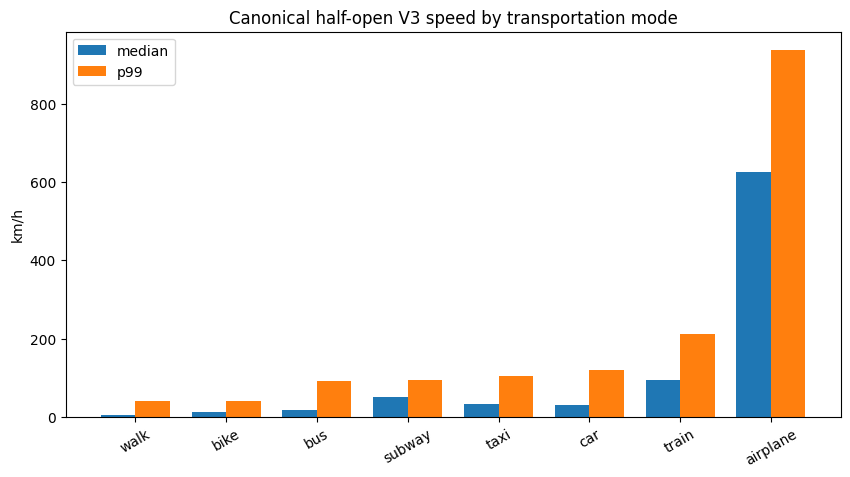

In [28]:
plot_df = mode_speed_summary_v3[
    mode_speed_summary_v3["mode"].isin(
        ["walk", "bike", "bus", "car", "taxi", "subway", "train", "airplane"]
    )
].copy().sort_values("p99_kmh")

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(plot_df))
width = 0.38
ax.bar(x - width/2, plot_df["median_kmh"], width, label="median")
ax.bar(x + width/2, plot_df["p99_kmh"], width, label="p99")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["mode"], rotation=30)
ax.set(
    title="Canonical half-open V3 speed by transportation mode",
    ylabel="km/h",
)
ax.legend()
plt.show()

Điều quan trọng là shape của central/tail distribution:

- airplane phải nằm ở vùng high-speed hợp lý;
- train cao hơn road modes;
- road modes thấp hơn;
- walk/bike thấp nhất;
- các max multi-thousand km/h là evidence rằng label membership không đồng nghĩa clean GPS.

# 11. Cleaning contract proposal sau EDA

EDA hiện support pipeline proposal sau:

```text
raw GPS
  ↓
coordinate-domain validation
  ↓
same-second consolidation
  compact <= 10 m → median representative
  conflict > 10 m → continuity boundary
  ↓
temporal continuity boundary
  max_gap_s sensitivity: 120 / 300 / 600 s
  ↓
conservative hard-speed corruption boundary
  candidate: 1200 km/h
  ↓
stay-point detector per sequence_id
```

### Điều **không** nên làm

- không dùng generic `>100`, `>200`, `>500 km/h => noise`;
- không interpolate qua long gaps;
- không invent sub-second ordering;
- không tự động delete endpoint chỉ vì segment speed rất cao;
- không dùng transportation mode labels làm Home/Office ground truth;
- không dedup cross-user files trong inference chỉ vì SHA giống nhau.

`1200 km/h` vẫn là **release-specific proposal**, chỉ freeze sau khi V3 half-open benchmark được rerun và review.

# 12. Stay-point baseline sau khi contract được approve

Đây là bước **sau EDA**, không phải threshold đã được EDA chứng minh là tối ưu.

Baseline candidate:

- distance threshold: **200 m**
- minimum dwell: **20 phút**
- continuity gap baseline: **5 phút**

Sensitivity grid sau khi implementation GREEN:

- `max_gap_s`: 120 / 300 / 600 s
- distance: 100 / 200 / 300 m
- dwell: 10 / 20 / 30 min

Mục tiêu sensitivity không phải maximize một con số vô nghĩa, mà kiểm tra:

- số staypoints/user;
- duration distribution;
- repeated-location stability;
- coverage users;
- downstream Home/Office heuristic stability.

---

## Trạng thái sau khi chạy notebook

Nếu toàn bộ cells chạy thành công và các audit targets khớp, EDA có thể được xem là **closed for CP1 cleaning decisions**.

Bước tiếp theo không phải đào EDA thêm, mà là:

**contract review → RED tests → preprocessing implementation → stay-point detector → bounded sensitivity → Home/Office heuristic.**